In [1]:
!pip install pesq
!pip install pystoi

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284125 sha256=266a7c02e853a95a02bf94009dd48e6378cbd60fe2907d5b8e9dd66d9cc66fa7
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq


In [2]:

import numpy as np
import librosa
import soundfile as sf
import os
import gc
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from numpy.linalg import norm
import torch
import torchaudio


import librosa.display
import matplotlib.pyplot as plt
from pesq import pesq
from pystoi import stoi


In [3]:
# Preprocessing Configuration
SAMPLE_RATE = 8000
FRAME_LENGTH = 8064
N_FFT = 255
HOP_LENGTH = 63
SNR = 0
DIM_SQUARE_SPEC = int(N_FFT / 2) + 1  # 128

In [4]:
male_DIR = '/kaggle/input/separation-dataset/m_train_grid.wav'
female_DIR = '/kaggle/input/separation-dataset/f_train_grid.wav'

In [5]:
male, sr = librosa.load(male_DIR, sr=SAMPLE_RATE)
female, sr = librosa.load(female_DIR, sr=SAMPLE_RATE)

In [6]:
l = min(male.shape[0], female.shape[0])
male = male[:l]
female = female[:l]
nb_samples = male.shape[0]
female.shape, male.shape

((164249536,), (164249536,))

In [7]:
def mixed_male_with_female(male, female, frame_length, snr):
    # Trim signals to be multiple of frame_length
    nb_samples = min(len(male), len(female))
    nb_frames = nb_samples // frame_length

    # Truncate signals to full frames only
    male = male[:nb_frames * frame_length].reshape(nb_frames, frame_length)
    female = female[:nb_frames * frame_length].reshape(nb_frames, frame_length)

    prod_male = np.zeros_like(male)
    prod_female = np.zeros_like(female)
    prod_mixed_male = np.zeros_like(male)

    for i in range(nb_frames):
        prod_male[i, :] = male[i, :]
        norm_male = np.linalg.norm(male[i, :])
        norm_female = np.linalg.norm(female[i, :])
        if norm_female > 0 and norm_male > 0:
            prod_female[i, :] = (female[i, :] / norm_female) * (norm_male * 10 ** (-snr / 20))
        prod_mixed_male[i, :] = prod_male[i, :] + prod_female[i, :]

    return prod_male, prod_female, prod_mixed_male

In [8]:
prod_male, prod_female, prod_mixed = mixed_male_with_female(male, female, FRAME_LENGTH, SNR)
del female
del male

In [9]:
def calculate_stft(n_fft, hop_length_fft, audio):
    stftaudio = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length_fft)
    mag, phase= librosa.magphase(stftaudio)
    return mag, phase

In [10]:
def extract_stft_features(numpy_audio, dim_square_spec, n_fft, hop_length_fft):
    nb_audio = numpy_audio.shape[0]
    mag = np.zeros((nb_audio, dim_square_spec, dim_square_spec))
    phase = np.zeros((nb_audio, dim_square_spec, dim_square_spec), dtype=complex)
    for i in range(nb_audio):
        mag[i, :, :], phase[i, :, :] = calculate_stft(n_fft, hop_length_fft, numpy_audio[i])
    return mag, phase

In [11]:
male_mag, male_phase= extract_stft_features(prod_male, DIM_SQUARE_SPEC, N_FFT, HOP_LENGTH)
del prod_male;gc.collect()
print(f"male mean: {male_mag.mean():.4f}, male std: {male_mag.std():.4f}")

male mean: 0.1593, male std: 0.4590


In [12]:
mixed_mag, mixed_phase= extract_stft_features(prod_mixed, DIM_SQUARE_SPEC, N_FFT, HOP_LENGTH)
del prod_female, prod_mixed;gc.collect()

0

In [13]:
# Magnitude
mixed_mag = mixed_mag ** 0.3
male_mag = male_mag ** 0.3


def normalize_phase_cyclic(phase_matrix):
    phase_sin = np.sin(phase_matrix)
    phase_cos = np.cos(phase_matrix)    
    return phase_sin, phase_cos


mixed_mag = torch.tensor(mixed_mag, dtype=torch.float32)
mixed_phase = np.angle(mixed_phase)
mixed_phase_sin, mixed_phase_cos = normalize_phase_cyclic(mixed_phase)
mixed_phase_sin = torch.tensor(mixed_phase_sin, dtype=torch.float32)
mixed_phase_cos = torch.tensor(mixed_phase_cos, dtype=torch.float32)


male_mag = torch.tensor(male_mag, dtype=torch.float32)
male_phase = np.angle(male_phase)
male_phase_sin, male_phase_cos = normalize_phase_cyclic(male_phase)
male_phase_sin = torch.tensor(male_phase_sin, dtype=torch.float32)
male_phase_cos = torch.tensor(male_phase_cos, dtype=torch.float32)

mixed_train = torch.stack((mixed_mag, mixed_phase_sin, mixed_phase_cos), dim=1)
male_train = torch.stack((male_mag, male_phase_sin, male_phase_cos), dim=1)
mixed_train.shape, male_train.shape
del male_mag, male_phase, male_phase_sin, male_phase_cos, mixed_mag, mixed_phase, mixed_phase_sin, mixed_phase_cos
gc.collect()

0

In [14]:
# Split into train and test sets
mixed_train, mixed_test, male_train, male_test = train_test_split(
    mixed_train, male_train, test_size=0.2, random_state=42
)


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ===============================
# Double Convolution Block
# ===============================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Dropout2d(p=0.05),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Dropout2d(p=0.05)
        )

    def forward(self, x):
        return self.double_conv(x)


# ===============================
# Downsample Block
# ===============================
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


# ===============================
# Upsample Block
# ===============================
class Up(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels, out_channels, kernel_size=2, stride=2
        )
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


# ===============================
# Paper-Faithful Bi-LSTM Bottleneck
# ===============================
class BiLSTM_Bottleneck(nn.Module):
    def __init__(self, channels, freq_bins):
        super().__init__()

        input_dim = channels * freq_bins  # e.g., 512 × 8 = 4096

        # 3 stacked Bi-LSTM layers (128 cells)
        self.bilstm1 = nn.LSTM(input_dim, 128, batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(256, 128, batch_first=True, bidirectional=True)
        self.bilstm3 = nn.LSTM(256, 128, batch_first=True, bidirectional=True)

        # Dense layer (64 units, Tanh)
        self.fc = nn.Sequential(
            nn.Linear(256, 64),
            nn.Tanh()
        )

        # Final Bi-LSTM
        self.bilstm_final = nn.LSTM(
            64, input_dim // 2, batch_first=True, bidirectional=True
        )

        self.norm = nn.LayerNorm(input_dim)

    def forward(self, x):
        # x: (B, C, F, T)
        B, C, F, T = x.shape

        # (B, T, C*F)
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(B, T, C * F)

        x, _ = self.bilstm1(x)
        x, _ = self.bilstm2(x)
        x, _ = self.bilstm3(x)

        x = self.fc(x)

        x, _ = self.bilstm_final(x)
        x = self.norm(x)

        # Back to CNN shape → (B, C, F, T)
        x = x.view(B, T, C, F).permute(0, 2, 3, 1)

        return x


# ===============================
# CNN-BiLSTM-UNet (FINAL MODEL)
# ===============================
class CNN_BiLSTM_UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.inc = DoubleConv(3, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)

        # Bottleneck (128 → 8 freq bins after pooling)
        self.bottleneck = BiLSTM_Bottleneck(channels=512, freq_bins=8)

        # Decoder
        self.up4 = Up(512, 512, 512)
        self.up3 = Up(512, 256, 256)
        self.up2 = Up(256, 128, 128)
        self.up1 = Up(128, 64, 64)

        self.outc = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x5 = self.bottleneck(x5)

        x = self.up4(x5, x4)
        x = self.up3(x, x3)
        x = self.up2(x, x2)
        x = self.up1(x, x1)

        return self.outc(x)


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if __name__ == "__main__":
    model = CNN_BiLSTM_UNet().to(device)
    x = torch.randn(2, 3, 128, 128).to(device)
    y = model(x)
    print("Output shape:", y.shape)
    print("Parameters:", sum(p.numel() for p in model.parameters()) // 1_000_000, "M")
    if torch.cuda.device_count() > 1:
        print(f"🖥️ Using {torch.cuda.device_count()} GPUs")
        model = torch.nn.DataParallel(model)


Output shape: torch.Size([2, 3, 128, 128])
Parameters: 60 M


In [17]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Hyperparameters
learning_rate = 0.0004
batch_size = 8

In [18]:
# Convert numpy arrays to PyTorch datasets
train_dataset = TensorDataset(mixed_train, male_train)
test_dataset = TensorDataset(mixed_test, male_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,  # increase if memory allows
    shuffle=True,
    num_workers=4,  # try 4–8 depending on CPU
    pin_memory=True,
)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
del train_dataset, test_dataset
gc.collect()

72

In [19]:
# Get the number of samples in the dataset
num_samples = len(train_loader)
print("Number of samples in train_dataset:", num_samples)


Number of samples in train_dataset: 2037


In [20]:
# L1 loss is less sensitive to outliers
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

In [21]:
patience = 20
num_epochs = 200
# Track losses
train_losses = []
test_losses = []

def save_checkpoint(model, optimizer, scheduler, epoch, best_test_loss, no_improvement):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'best_test_loss': best_test_loss,
        'no_improvement': no_improvement,
        'train_losses': train_losses,
        'test_losses': test_losses,
    }
    torch.save(checkpoint, 'checkpoint.pth')
    print("Checkpoint saved.")

def load_checkpoint(model, optimizer, scheduler):
    try:
        checkpoint = torch.load('/kaggle/input/vit-unet-32-512-c-m-100-p-10/pytorch/default/1/vit-unet-32-512-c-m-100-p-10_checkpoint_1-44.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_test_loss = checkpoint['best_test_loss']
        no_improvement = checkpoint['no_improvement']
        train_losses[:] = checkpoint['train_losses']
        test_losses[:] = checkpoint['test_losses']
        print(f"Resumed training from epoch {start_epoch}")
        return start_epoch, best_test_loss, no_improvement
    except FileNotFoundError:
        print("No checkpoint found. Starting from scratch.")
        return 1, float('inf'), 0

from torch.amp import autocast, GradScaler

scaler = GradScaler(device="cuda")

def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0.0

    for batch_idx, (mixed, clean) in enumerate(train_loader):
        mixed, clean = mixed.to(device), clean.to(device)
        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            outputs = model(mixed)
            loss = criterion(outputs, clean)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch} — Train Loss: {avg_loss:.4f}")
    return avg_loss

def test(model, device, test_loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for mixed, clean in test_loader:
            mixed, clean = mixed.to(device), clean.to(device)

            with autocast(device_type='cuda'):
                outputs = model(mixed)
                loss = criterion(outputs, clean)

            total_loss += loss.item()

    avg_loss = total_loss / len(test_loader)
    test_losses.append(avg_loss)
    print(f"Test Loss: {avg_loss:.4f}")
    return avg_loss

In [22]:
# Load checkpoint (if exists)
start_epoch, best_test_loss, no_improvement = load_checkpoint(model, optimizer, scheduler)

# Set the end epoch (either 10 more or max 50)

for epoch in range(start_epoch, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    train_loss = train(model, device, train_loader, optimizer, criterion, epoch)
    test_loss = test(model, device, test_loader, criterion)
    scheduler.step(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        no_improvement = 0
        torch.save(model.state_dict(), f'best_model.pth')
        print(f"Saved new best model (Loss: {best_test_loss:.6f})")
    else:
        no_improvement += 1
        print(f"No improvement for {no_improvement}/{patience} epochs")

    save_checkpoint(model, optimizer, scheduler, epoch, best_test_loss, no_improvement)

    if no_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch}!")
        break
        

No checkpoint found. Starting from scratch.

Epoch 1/200
Epoch 1 — Train Loss: 0.2849
Test Loss: 0.2617
Saved new best model (Loss: 0.261733)
Checkpoint saved.

Epoch 2/200
Epoch 2 — Train Loss: 0.2659
Test Loss: 0.2512
Saved new best model (Loss: 0.251191)
Checkpoint saved.

Epoch 3/200
Epoch 3 — Train Loss: 0.2590
Test Loss: 0.2458
Saved new best model (Loss: 0.245813)
Checkpoint saved.

Epoch 4/200
Epoch 4 — Train Loss: 0.2549
Test Loss: 0.2436
Saved new best model (Loss: 0.243563)
Checkpoint saved.

Epoch 5/200
Epoch 5 — Train Loss: 0.2517
Test Loss: 0.2404
Saved new best model (Loss: 0.240358)
Checkpoint saved.

Epoch 6/200
Epoch 6 — Train Loss: 0.2495
Test Loss: 0.2393
Saved new best model (Loss: 0.239341)
Checkpoint saved.

Epoch 7/200
Epoch 7 — Train Loss: 0.2476
Test Loss: 0.2366
Saved new best model (Loss: 0.236585)
Checkpoint saved.

Epoch 8/200
Epoch 8 — Train Loss: 0.2460
Test Loss: 0.2356
Saved new best model (Loss: 0.235591)
Checkpoint saved.

Epoch 9/200
Epoch 9 — Train

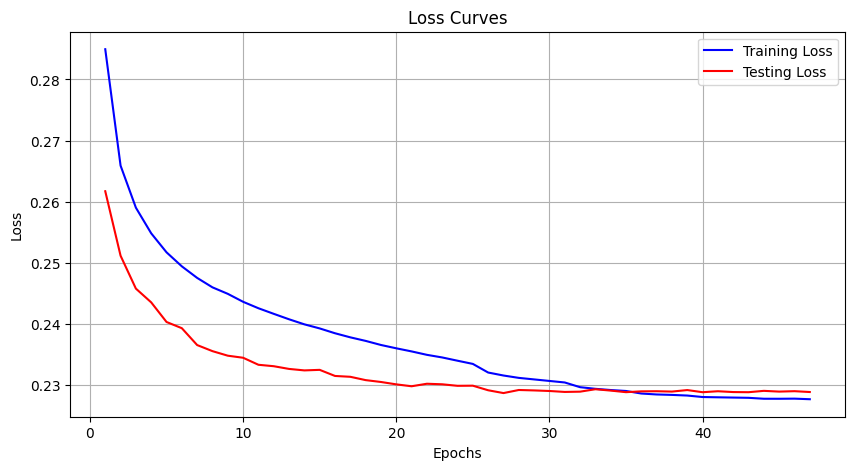

In [23]:
import matplotlib.pyplot as plt

# After training and testing
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Testing Loss', color='red')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Save the plot to output
plt.savefig('/kaggle/working/loss_curves.png')  # Save in Kaggle working directory

plt.show()  # Display the plot


In [24]:
import torch
import torch.nn as nn
from collections import OrderedDict

# ---------- 1. Collect activations ----------
def get_activations(model, x):
    activations = OrderedDict()

    def hook_fn(name):
        def hook(module, inp, out):
            activations[name] = out.detach().clone().cpu().numpy()
        return hook

    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear, nn.BatchNorm2d)):
            hooks.append(layer.register_forward_hook(hook_fn(name)))

    
    _ = model(x)

    for h in hooks: h.remove()
    return activations

# ---------- 2. Module-level gradients ----------
def get_gradients(model, x, y, criterion):
    model.train(); model.zero_grad()
    gradients = OrderedDict()

    def grad_hook(name):
        def hook(module, grad_input, grad_output):
            g = grad_output[0].detach().clone().cpu().numpy()
            gradients[name] = g
        return hook

    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.Conv2d, nn.Linear, nn.ConvTranspose2d)):
            hooks.append(layer.register_full_backward_hook(grad_hook(name)))

    out = model(x)
    corr = torch.corrcoef(torch.stack([out.flatten(), y.flatten()]))[0,1].item()
    print(f"Output-target correlation: {corr:.4f}")
    loss = criterion(out, y)
    loss.backward()

    for h in hooks: h.remove()
    return gradients, loss.item()

# ---------- 3. Parameter-level gradients ----------
def get_param_gradients(model, x, y, criterion):
    model.train(); model.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()

    grads = OrderedDict()
    for name, p in model.named_parameters():
        if p.grad is not None:
            grads[name] = p.grad.detach().cpu().numpy()
    return grads, loss.item()

# ---------- 4. Tensor output gradients ----------
def get_tensor_output_grads(model, x, y, criterion):
    model.train(); model.zero_grad()
    act_grads = OrderedDict()

    def forward_hook(name):
        def hook(module, inp, out):
            out.retain_grad()
            def tensor_hook(grad):
                act_grads[name] = grad.detach().cpu().numpy()
            out.register_hook(tensor_hook)
        return hook

    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            hooks.append(layer.register_forward_hook(forward_hook(name)))

    out = model(x)
    loss = criterion(out, y)
    loss.backward()

    for h in hooks: h.remove()
    return act_grads, loss.item()

# ---------- 5. Ablation Study ----------
def ablation_test(model, x, y, criterion):
    model.train()
    
    base_loss = criterion(model(x), y).item()

    layer_importance = {}
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.BatchNorm2d, nn.BatchNorm1d, nn.LayerNorm)):
            continue
        if not hasattr(layer, "weight") or layer.weight is None:
            continue

        w_backup = layer.weight.data.clone()
        b_backup = layer.bias.data.clone() if hasattr(layer, "bias") and layer.bias is not None else None

        layer.weight.data.zero_()
        if b_backup is not None:
            layer.bias.data.zero_()

        
        loss = criterion(model(x), y).item()

        layer.weight.data.copy_(w_backup)
        if b_backup is not None:
            layer.bias.data.copy_(b_backup)

        layer_importance[name] = loss - base_loss

    return layer_importance, base_loss

# ---------- 6. Unified Report ----------
def print_model_analysis(activations, gradients, param_grads, tensor_grads, ablation, base_loss, top_k=20):
    print("\n============== MODEL DIAGNOSTIC REPORT ==============\n")

    print("🟦 ACTIVATION HEALTH")
    for name, act in activations.items():
        print(f"{name:30s} | mean={act.mean():.6f} | std={act.std():.6f}")

    print("\n🟥 MODULE GRADIENTS")
    grad_items = [(n, g) for n, g in gradients.items()]
    grad_items.sort(key=lambda x: x[1].std(), reverse=True)
    for name, g in grad_items[:top_k]:
        print(f"{name:30s} | grad_mean={g.mean():.6f} | grad_std={g.std():.6f}")

    print("\n🟥 PARAMETER GRADIENTS")
    for name, g in list(param_grads.items())[:top_k]:
        print(f"{name:30s} | grad_mean={g.mean():.6f} | grad_std={g.std():.6f}")

    print("\n🟥 TENSOR OUTPUT GRADIENTS")
    for name, g in list(tensor_grads.items())[:top_k]:
        print(f"{name:30s} | grad_mean={g.mean():.6f} | grad_std={g.std():.6f}")

    print("\n🟨 LAYER IMPORTANCE (Ablation ΔLoss)")
    sorted_layers = sorted(ablation.items(), key=lambda x: abs(x[1]), reverse=True)
    for name, dloss in sorted_layers[:top_k]:
        print(f"{name:30s} | ΔLoss = {dloss:.6f}")

    print(f"\nBaseline loss: {base_loss:.6f}")
    print("\n============== END OF REPORT ==============\n")


best_model = model
best_model.load_state_dict(torch.load("best_model.pth", map_location=device))
best_model.eval()

mixed_batch, clean_batch = next(iter(test_loader))
mixed_batch, clean_batch = mixed_batch.to(device), clean_batch.to(device)

# Run diagnostics
acts = get_activations(best_model, mixed_batch)
grads, _ = get_gradients(best_model, mixed_batch, clean_batch, criterion)
param_grads, _ = get_param_gradients(best_model, mixed_batch, clean_batch, criterion)
tensor_grads, _ = get_tensor_output_grads(best_model, mixed_batch, clean_batch, criterion)
ablation_scores, ablation_base = ablation_test(best_model, mixed_batch, clean_batch, criterion)

# Print full report
print_model_analysis(acts, grads, param_grads, tensor_grads, ablation_scores, ablation_base)

Output-target correlation: 0.7696


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



============== MODEL DIAGNOSTIC REPORT ==============

🟦 ACTIVATION HEALTH
inc.double_conv.0              | mean=-0.009104 | std=0.437395
inc.double_conv.1              | mean=-0.045779 | std=0.595753
inc.double_conv.4              | mean=-0.366465 | std=1.312059
inc.double_conv.5              | mean=-0.128434 | std=0.623345
down1.block.1.double_conv.0    | mean=-1.128037 | std=1.782873
down1.block.1.double_conv.1    | mean=-0.263413 | std=0.880584
down1.block.1.double_conv.4    | mean=-0.945479 | std=2.797651
down1.block.1.double_conv.5    | mean=-0.433620 | std=0.854134
down2.block.1.double_conv.0    | mean=-2.034009 | std=2.906662
down2.block.1.double_conv.1    | mean=-0.483923 | std=0.993113
down2.block.1.double_conv.4    | mean=-1.126598 | std=3.327101
down2.block.1.double_conv.5    | mean=-0.532588 | std=0.996671
down3.block.1.double_conv.0    | mean=-3.691863 | std=5.306065
down3.block.1.double_conv.1    | mean=-0.608933 | std=1.011626
down3.block.1.double_conv.4    | mean=-1.2

In [25]:
def run_evaluation_test(base_path, male_path, female_path, save_png):
    male, _ = librosa.load(male_path, sr=SAMPLE_RATE)
    female, _ = librosa.load(female_path, sr=SAMPLE_RATE)

    _, _, mixed_frames = mixed_male_with_female(male, female, FRAME_LENGTH, SNR)
    
    # ========== INFERENCE ==========
    mixed_mag, mixed_phase = extract_stft_features(mixed_frames, DIM_SQUARE_SPEC, N_FFT, HOP_LENGTH)
    mixed_mag = mixed_mag ** 0.3
    mixed_mag = torch.tensor(mixed_mag, dtype=torch.float32)
    mixed_phase = np.angle(mixed_phase)
    mixed_phase_sin, mixed_phase_cos = normalize_phase_cyclic(mixed_phase)
    mixed_phase_sin = torch.tensor(mixed_phase_sin, dtype=torch.float32)
    mixed_phase_cos = torch.tensor(mixed_phase_cos, dtype=torch.float32)
    
    mixed_train = torch.stack((mixed_mag, mixed_phase_sin, mixed_phase_cos), dim=1)
    del mixed_mag, mixed_phase, mixed_phase_sin, mixed_phase_cos
    gc.collect()
    
    mixed_train = mixed_train.to(device)
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    model.eval()
    
    with torch.no_grad():
        pred = model(mixed_train).cpu().numpy()

    del mixed_train
    gc.collect()

    # ========== POSTPROCESSING ==========
    pred_mag = pred[:, 0, :, :]
    pred_sin = pred[:, 1, :, :]
    pred_cos = pred[:, 2, :, :]
    
    # Convert log magnitude back to linear
    pred_mag_linear = np.clip(pred_mag, 0.0, None) ** (1.0 / 0.3)
    # Normalize phase outputs
    norm = np.sqrt(pred_sin**2 + pred_cos**2) + 1e-10
    pred_sin = pred_sin / norm
    pred_cos = pred_cos / norm
    
    # ========== RECONSTRUCT EACH FRAME ==========
    enhanced_frames = []
    for i in range(len(pred_mag_linear)):
        # Reconstruct complex spectrogram for this frame
        complex_phase = pred_cos[i] + 1j * pred_sin[i]
        complex_matrix = pred_mag_linear[i] * complex_phase
        
        # ISTFT for this frame
        frame_audio = librosa.istft(
            complex_matrix, 
            n_fft=N_FFT, 
            hop_length=HOP_LENGTH,
            length=FRAME_LENGTH  # This is correct per frame
        )
        enhanced_frames.append(frame_audio)
    
    # Combine all frames
    enhanced = np.concatenate(enhanced_frames)
    
    # Trim to match original male length
    female = female[:len(enhanced)]#    
    ref = male[:len(enhanced)]#
    deg = enhanced#
    mix=mixed_frames.reshape(-1)
    mix=mix[:len(enhanced)]
    enhanced_female=mix-deg
    
    
    # ========== METRICS ==========
    print(f"clean mean: {ref.mean():.4f}, clean std: {ref.std():.4f}")    
    print(f"enhanced mean: {deg.mean():.4f}, enhanced std: {deg.std():.4f}")    
    print(f"PESQ: {pesq(SAMPLE_RATE, ref, deg, 'nb'):.3f}")
    print(f"STOI: {stoi(ref, deg, SAMPLE_RATE, False):.3f}\n")

    # ========== Save File ==========
    output_dir = os.path.join(base_path, "results")
    os.makedirs(output_dir, exist_ok=True)
    
    sf.write(os.path.join(output_dir, "clean_male.wav"), ref, SAMPLE_RATE)
    sf.write(os.path.join(output_dir, "clean_female.wav"), female, SAMPLE_RATE)
    sf.write(os.path.join(output_dir, "enhanced_male.wav"), deg, SAMPLE_RATE)
    sf.write(os.path.join(output_dir, "mixed.wav"), mix, SAMPLE_RATE)
    sf.write(os.path.join(output_dir, "enhanced_female.wav"), enhanced_female, SAMPLE_RATE)
        
    # ========== CLEANUP ==========
    del pred_mag, pred_sin, pred_cos, pred_mag_linear, enhanced, ref, deg, male
    gc.collect()
    torch.cuda.empty_cache()
    

# ============================================================
# RUN
# ============================================================
speech_files = [f"M{i:02d}" for i in range(1, 11)]
female_files = [f"clean_f{i:02d}_output.wav" for i in range(10)]
for n in female_files:
    female_path = f"/kaggle/input/clipping-seperation-dataseet/M01/clean_female/{n}"
    print(n)
    for s in speech_files:
        male_path = f"/kaggle/input/clipping-seperation-dataseet/{s}/clean_male/clean_male01.wav"
        save_png = f"{s.split('.')[0]}+{n.replace('.wav','')}.png"
        run_evaluation_test(n, male_path, female_path, save_png)




clean_f00_output.wav
clean mean: 0.0003, clean std: 0.0467
enhanced mean: 0.0003, enhanced std: 0.0437
PESQ: 3.851
STOI: 0.980

clean mean: 0.0003, clean std: 0.0465
enhanced mean: 0.0003, enhanced std: 0.0439
PESQ: 3.673
STOI: 0.980

clean mean: 0.0003, clean std: 0.0445
enhanced mean: 0.0003, enhanced std: 0.0419
PESQ: 3.710
STOI: 0.981

clean mean: 0.0003, clean std: 0.0451
enhanced mean: 0.0003, enhanced std: 0.0427
PESQ: 3.706
STOI: 0.984

clean mean: 0.0003, clean std: 0.0499
enhanced mean: 0.0003, enhanced std: 0.0463
PESQ: 3.622
STOI: 0.975

clean mean: 0.0004, clean std: 0.0499
enhanced mean: 0.0003, enhanced std: 0.0469
PESQ: 3.853
STOI: 0.979

clean mean: 0.0008, clean std: 0.0499
enhanced mean: 0.0007, enhanced std: 0.0472
PESQ: 3.686
STOI: 0.985

clean mean: 0.0006, clean std: 0.0498
enhanced mean: 0.0007, enhanced std: 0.0467
PESQ: 3.321
STOI: 0.959

clean mean: 0.0006, clean std: 0.0499
enhanced mean: 0.0006, enhanced std: 0.0467
PESQ: 3.200
STOI: 0.963

clean mean: 0.00